# VAE FiLM + Spectral Loss 학습 노트북
## ★ 파라미터만 바꿔서 4명이 동시 실행

### 버그 수정 내역 (태라 v1 대비)
- `istft hop_length=40` → `HOP_LENGTH=46` 통일
- val loop에 `true_phase`, `true_wf` 누락 → 추가
- wandb `epoch` 변수 오타(`e`) → `epoch` 수정
- val loss가 train과 다른 loss 계산하던 문제 → 통일

### 사용법
1. **셀 1개만 수정** → `## ★ 여기만 수정` 섹션
2. 위에서 아래로 순서대로 전체 실행
3. wandb에서 실시간 확인

## ★ 여기만 수정 — 파라미터 설정

In [106]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ★★★ 4명이 각자 여기만 바꾸면 됨 ★★★
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

RUN_NAME = "재형-C1-beta1.0-spec1.0-mr0.5-rank5.0-encfilm-retrain5"
BETA_MAX        = 1.0
LAMBDA_SPECTRAL = 1.0
LAMBDA_MRSTFT   = 0.5
LAMBDA_RANK     = 5  # 추가

# 학습 설정
N_EPOCHS        = 100    # 에포크 수
N_TRAIN         = 20000  # train 샘플 수 (최대 157698)
N_VAL           = 4000   # val 샘플 수

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 아래는 건드리지 말 것
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# wandb 설정
WANDB_ENTITY    = "joonoo-kwak-korea-university"
WANDB_PROJECT   = "seismic-vae"
WANDB_API_KEY   = ""   # 비워두면 실행 시 입력 창 뜸

# 경로
STEAD_CSV  = '/content/drive/MyDrive/ML_Project/chunk3.csv'
DRIVE_HDF5 = '/content/drive/MyDrive/ML_Project/chunk3.hdf5'
LOCAL_HDF5 = '/content/chunk3.hdf5'
SAVE_DIR   = f'/content/drive/MyDrive/ML_Project/outputs/film_vae/{RUN_NAME}'

print(f"실험명  : {RUN_NAME}")
print(f"BETA_MAX: {BETA_MAX}, λ_spec: {LAMBDA_SPECTRAL}, λ_mr: {LAMBDA_MRSTFT}")
print(f"epochs  : {N_EPOCHS}, train: {N_TRAIN}개, val: {N_VAL}개")
print(f"저장 경로: {SAVE_DIR}")

실험명  : 재형-C1-beta1.0-spec1.0-mr0.5-rank5.0-encfilm-retrain5
BETA_MAX: 1.0, λ_spec: 1.0, λ_mr: 0.5
epochs  : 100, train: 20000개, val: 4000개
저장 경로: /content/drive/MyDrive/ML_Project/outputs/film_vae/재형-C1-beta1.0-spec1.0-mr0.5-rank5.0-encfilm-retrain5


## 1. 환경 세팅

In [107]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [108]:
!pip install h5py torch torchaudio numpy pandas wandb scikit-learn matplotlib -q
print('패키지 설치 완료')

패키지 설치 완료


In [109]:
import os, json, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import h5py
import wandb
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
assert str(device) == 'cuda', "GPU가 없습니다. 런타임 → GPU로 변경하세요."

os.makedirs(SAVE_DIR, exist_ok=True)

device: cuda


In [110]:
# HDF5 로컬 복사 (Drive I/O 병목 방지 — 5~10분 소요)
if not os.path.exists(LOCAL_HDF5):
    print('HDF5 복사 중... (5~10분)')
    shutil.copy(DRIVE_HDF5, LOCAL_HDF5)
    print('복사 완료!')
else:
    print('이미 로컬에 존재, 스킵')

STEAD_HDF5 = LOCAL_HDF5
print(f'hdf5: {os.path.exists(STEAD_HDF5)}')
print(f'csv : {os.path.exists(STEAD_CSV)}')

이미 로컬에 존재, 스킵
hdf5: True
csv : True


## 2. 고정 설정 (건드리지 말 것)

In [111]:
# STFT 설정 — 준우 기준, 전체 파이프라인과 통일
SR         = 100
N_FFT      = 160
HOP_LENGTH = 46       # ★ istft에서도 반드시 이 값 사용
WIN_LENGTH = 160
N_FREQ     = N_FFT // 2 + 1   # 81
N_SAMPLES  = 6000
N_TIME     = N_SAMPLES // HOP_LENGTH + 1  # 131

# 조건 변수
COND_COLS = [
    'source_magnitude',
    'source_latitude', 'source_longitude',
    'receiver_latitude', 'receiver_longitude',
    'source_depth_km'
]

# 모델 구조
LATENT_DIM = 16
HIDDEN_DIM = 256
BATCH_SIZE = 64
LR         = 3e-4
WEIGHT_DECAY = 1e-7

print(f'N_FREQ={N_FREQ}, N_TIME={N_TIME}, HOP_LENGTH={HOP_LENGTH}')
print('고정 설정 완료')

N_FREQ=81, N_TIME=131, HOP_LENGTH=46
고정 설정 완료


## 3. 데이터 준비

In [112]:
metadata = pd.read_csv(STEAD_CSV, low_memory=False)
print(f'전체: {len(metadata):,}개')

train_meta = metadata[metadata['source_magnitude'] < 4.0].copy()
test_meta  = metadata[metadata['source_magnitude'] >= 4.0].copy().reset_index(drop=True)
train_meta, val_meta = train_test_split(train_meta, test_size=0.2, random_state=42)

print(f'train (M<4): {len(train_meta):,}개')
print(f'val   (M<4): {len(val_meta):,}개')
print(f'test  (M≥4): {len(test_meta):,}개')

# 조건 정규화 통계 (train 기준)
cond_min = train_meta[COND_COLS].min()
cond_max = train_meta[COND_COLS].max()
cond_max['source_magnitude'] = 8.0

with open(os.path.join(SAVE_DIR, 'cond_norm_stats.json'), 'w') as f:
    json.dump({'min': cond_min.to_dict(), 'max': cond_max.to_dict()}, f, indent=2)
print('정규화 통계 저장 완료')

전체: 200,000개
train (M<4): 157,698개
val   (M<4): 39,425개
test  (M≥4): 2,877개
정규화 통계 저장 완료


In [113]:
# 층화 샘플링 (magnitude 분포 보존)
def stratified_sample(meta_df, n_samples, random_state=42):
    meta_df = meta_df.copy()
    meta_df['mag_bin'] = pd.cut(
        meta_df['source_magnitude'],
        bins=[-1, 1, 2, 3, 4],
        labels=['M<1', 'M1-2', 'M2-3', 'M3-4']
    )
    sampled = meta_df.groupby('mag_bin', observed=True).apply(
        lambda x: x.sample(
            n=max(1, int(n_samples * len(x) / len(meta_df))),
            random_state=random_state
        ), include_groups=False
    ).reset_index(drop=True)
    return sampled

train_meta_s = stratified_sample(train_meta, n_samples=N_TRAIN)
val_meta_s   = stratified_sample(val_meta,   n_samples=N_VAL)

print(f'학습용 train: {len(train_meta_s):,}개')
print(f'학습용 val  : {len(val_meta_s):,}개')
print('\ntrain 분포:')
print(pd.cut(train_meta_s['source_magnitude'],
             bins=[-1,1,2,3,4]).value_counts().sort_index())

학습용 train: 19,997개
학습용 val  : 3,997개

train 분포:
source_magnitude
(-1, 1]    7791
(1, 2]     8623
(2, 3]     2777
(3, 4]      806
Name: count, dtype: int64


In [114]:
# log10 진폭 min/max 추정 (train 2000개 샘플 기준)
print('wfs 통계 추정 중...')
_window = torch.hann_window(WIN_LENGTH)
_sample = train_meta_s.sample(n=min(2000, len(train_meta_s)), random_state=42)
_all = []

with h5py.File(STEAD_HDF5, 'r') as hf:
    for _, row in _sample.iterrows():
        try:
            wf = hf['data'][row['trace_name']][:N_SAMPLES, 2].astype(np.float32)
        except KeyError:
            continue
        peak = np.abs(wf).max()
        if peak < 1e-10:
            continue
        wf = wf / peak
        stft = torch.stft(torch.from_numpy(wf),
                          n_fft=N_FFT, hop_length=HOP_LENGTH,
                          win_length=WIN_LENGTH, window=_window,
                          return_complex=True)
        _all.append(torch.log10(stft.abs() + 1e-10))

_all = torch.stack(_all)
WFS_MIN = _all.min().item()
WFS_MAX = _all.max().item()

# 전역 tensor (loss 함수에서 참조)
_wfs_min_t = torch.tensor(WFS_MIN)
_wfs_max_t = torch.tensor(WFS_MAX)

print(f'wfs_min: {WFS_MIN:.4f}')
print(f'wfs_max: {WFS_MAX:.4f}')

wfs 통계 추정 중...
wfs_min: -10.0000
wfs_max: 1.7219


In [115]:
class STEADDataset(Dataset):
    def __init__(self, meta_df, hdf5_path, wfs_min, wfs_max):
        self.meta      = meta_df.reset_index(drop=True)
        self.hdf5_path = hdf5_path
        self.wfs_min   = wfs_min
        self.wfs_max   = wfs_max
        self.cond_min  = torch.tensor(cond_min.values, dtype=torch.float32)
        self.cond_max  = torch.tensor(cond_max.values, dtype=torch.float32)
        self.window    = torch.hann_window(WIN_LENGTH)
        self.hdf5_file = None

    def _open(self):
        if self.hdf5_file is None:
            self.hdf5_file = h5py.File(self.hdf5_path, 'r')

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        self._open()
        row = self.meta.iloc[idx]

        try:
            wf = self.hdf5_file['data'][row['trace_name']][:N_SAMPLES, :].astype(np.float32)
            wf = wf.mean(axis=1)  # (6000, 3) → (6000,)
        except KeyError:
            wf = np.zeros(N_SAMPLES, dtype=np.float32)

        peak = np.abs(wf).max()
        if peak > 1e-10:
            wf = wf / peak
        wf_t = torch.from_numpy(wf)  # (6000,)

        stft = torch.stft(wf_t, n_fft=N_FFT, hop_length=HOP_LENGTH,
                          win_length=WIN_LENGTH, window=self.window,
                          return_complex=True)  # (N_FREQ, N_TIME)

        magnitude = stft.abs()
        phase     = stft.angle()

        log_amp = torch.log10(magnitude + 1e-10)
        log_amp = (log_amp - self.wfs_min) / (self.wfs_max - self.wfs_min + 1e-10)
        log_amp = log_amp.clamp(0, 1)

        # (N_FREQ, N_TIME) → (N_TIME, N_FREQ)
        log_amp = log_amp.T   # (131, 81)
        phase   = phase.T     # (131, 81)

        cond_vals = torch.tensor([row[c] for c in COND_COLS], dtype=torch.float32)
        cond_norm = (cond_vals - self.cond_min) / (self.cond_max - self.cond_min + 1e-10)
        cond_norm = cond_norm.clamp(0, 1)

        return log_amp, cond_norm, phase, wf_t

train_ds = STEADDataset(train_meta_s, STEAD_HDF5, WFS_MIN, WFS_MAX)
val_ds   = STEADDataset(val_meta_s,   STEAD_HDF5, WFS_MIN, WFS_MAX)
test_ds  = STEADDataset(test_meta,    STEAD_HDF5, WFS_MIN, WFS_MAX)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

_b = next(iter(train_loader))
print(f'log_amp : {_b[0].shape}')   # (64, 131, 81)
print(f'cond    : {_b[1].shape}')   # (64, 6)
print(f'phase   : {_b[2].shape}')   # (64, 131, 81)
print(f'wf      : {_b[3].shape}')   # (64, 6000)
print(f'train {len(train_loader)}배치 / val {len(val_loader)}배치')

log_amp : torch.Size([64, 131, 81])
cond    : torch.Size([64, 6])
phase   : torch.Size([64, 131, 81])
wf      : torch.Size([64, 6000])
train 313배치 / val 63배치


## 4. 모델 정의 (FiLM VAE)

In [116]:
class FiLMGenerator(nn.Module):
    """조건 c → 각 GRU 레이어용 (gamma, beta) 생성"""
    def __init__(self, cond_dim=6, num_layers=3, hidden_dim=128, feature_dim=256):
        super().__init__()
        self.num_layers = num_layers
        self.shared_mlp = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.gamma_layers = nn.ModuleList([nn.Linear(hidden_dim, feature_dim) for _ in range(num_layers)])
        self.beta_layers  = nn.ModuleList([nn.Linear(hidden_dim, feature_dim) for _ in range(num_layers)])
        # 초기값: gamma≈1, beta≈0 (학습 초기 안정성)
        for g in self.gamma_layers:
          nn.init.xavier_uniform_(g.weight)
          nn.init.ones_(g.bias)   # bias=1로 → gamma 출력이 초기에 1 근처
        for b in self.beta_layers:
          nn.init.zeros_(b.weight)
          nn.init.zeros_(b.bias)

    def forward(self, c):
        h = self.shared_mlp(c)
        return [g(h) for g in self.gamma_layers], [b(h) for b in self.beta_layers]


class FiLMLayer(nn.Module):
    """h' = gamma * h + beta  (B,T,F)"""
    def forward(self, h, gamma, beta):
        return gamma.unsqueeze(1) * h + beta.unsqueeze(1)


class FiLMEncoder(nn.Module):
    def __init__(self, in_freq=81, latent_dim=16, hidden=256, cond_dim=6):
        super().__init__()
        self.gru   = nn.GRU(in_freq, hidden, num_layers=2,
                            batch_first=True, bidirectional=True)
        self.film_gen = FiLMGenerator(cond_dim, num_layers=1,
                                       hidden_dim=128, feature_dim=hidden*2)
        self.film     = FiLMLayer()
        self.fc_mu = nn.Linear(hidden * 2, latent_dim)
        self.fc_lv = nn.Linear(hidden * 2, latent_dim)

    def forward(self, x, c):  # c 추가
        out, _ = self.gru(x)
        h = out[:, -1, :]
        gammas, betas = self.film_gen(c)
        h = self.film(h.unsqueeze(1), gammas[0], betas[0]).squeeze(1)
        return self.fc_mu(h), self.fc_lv(h)


class FiLMDecoder(nn.Module):
    """z (B, latent_dim) + c (B, cond_dim) → 복원 스펙트럼 (B, T, F)"""
    def __init__(self, latent_dim=16, cond_dim=6, out_freq=81, n_time=131, hidden=256):
        super().__init__()
        self.n_time     = n_time
        self.num_layers = 3
        self.fc_z       = nn.Sequential(nn.Linear(latent_dim, hidden), nn.ReLU())
        self.gru_layers = nn.ModuleList([
            nn.GRU(hidden, hidden, batch_first=True) for _ in range(self.num_layers)
        ])
        self.film_gen    = FiLMGenerator(cond_dim, self.num_layers, 128, hidden)
        self.film_layers = nn.ModuleList([FiLMLayer() for _ in range(self.num_layers)])
        self.fc_out      = nn.Linear(hidden, out_freq)

    def forward(self, z, c):
        h = self.fc_z(z).unsqueeze(1).expand(-1, self.n_time, -1)
        gammas, betas = self.film_gen(c)
        for i in range(self.num_layers):
            h, _ = self.gru_layers[i](h)
            h    = self.film_layers[i](h, gammas[i], betas[i])
        return self.fc_out(h)   # (B, T, F)


class FiLMVAE(nn.Module):
    def __init__(self, in_freq=81, n_time=131, latent_dim=16, cond_dim=6, hidden=256):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder    = FiLMEncoder(in_freq, latent_dim, hidden, cond_dim)  # cond_dim 추가
        self.decoder    = FiLMDecoder(latent_dim, cond_dim, in_freq, n_time, hidden)

    def reparameterize(self, mu, log_var):
        return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)

    def forward(self, x, c):
        mu, log_var = self.encoder(x, c)  # c 추가
        z           = self.reparameterize(mu, log_var)
        return self.decoder(z, c), mu, log_var

    def generate(self, c):
        z = torch.randn(c.size(0), self.latent_dim, device=c.device)
        return self.decoder(z, c)


model = FiLMVAE(
    in_freq=N_FREQ, n_time=N_TIME,
    latent_dim=LATENT_DIM, cond_dim=len(COND_COLS),
    hidden=HIDDEN_DIM
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'파라미터 수: {n_params:,}')

# 동작 확인
with torch.no_grad():
    _x = _b[0][:2].to(device)
    _c = _b[1][:2].to(device)
    _r, _mu, _lv = model(_x, _c)
    print(f'입력 {_x.shape} → 복원 {_r.shape}, mu {_mu.shape}')

파라미터 수: 3,294,321
입력 torch.Size([2, 131, 81]) → 복원 torch.Size([2, 131, 81]), mu torch.Size([2, 16])


## 5. 손실 함수

In [121]:
def multi_resolution_stft_loss(pred_wf, true_wf):
    """MR-STFT Loss — 여러 해상도에서 시간-주파수 차이 측정"""
    fft_sizes  = [64, 128, 256]
    hop_sizes  = [16, 32,  64]
    win_lengths= [64, 128, 256]

    if pred_wf.dim() == 2:
        pass  # (B, T) 그대로
    else:
        pred_wf = pred_wf.reshape(-1, pred_wf.shape[-1])
        true_wf = true_wf.reshape(-1, true_wf.shape[-1])

    loss_sc = loss_log = 0.0
    for n_fft, hop, win in zip(fft_sizes, hop_sizes, win_lengths):
        w = torch.hann_window(win).to(pred_wf.device)
        p = torch.stft(pred_wf, n_fft=n_fft, hop_length=hop, win_length=win, window=w, return_complex=True).abs() + 1e-7
        t = torch.stft(true_wf, n_fft=n_fft, hop_length=hop, win_length=win, window=w, return_complex=True).abs() + 1e-7
        loss_sc  += torch.norm(t - p, p='fro') / (torch.norm(t, p='fro') + 1e-7)
        loss_log += F.l1_loss(torch.log(t), torch.log(p))

    return (loss_sc + loss_log) / len(fft_sizes)


def film_vae_loss(X, X_hat, mu, log_var,
                  true_phase, true_wf,
                  beta, lambda_spectral, lambda_mrstft):
    """
    L = L_recon + beta*L_KL + lambda_spectral*L_fas_hf + lambda_mrstft*L_mrstft

    X, X_hat   : (B, T, F) 정규화된 log 진폭 스펙트럼
    true_phase : (B, T, F) 원본 위상
    true_wf    : (B, 6000) 원본 파형
    """
    B = X.shape[0]

    # 1. Reconstruction
    L_recon = F.mse_loss(X_hat, X, reduction='sum') / B

    # 2. KL Divergence
    L_KL = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / B

    # 3. FAS 고주파 페널티 (10Hz 이상 = freq bin 16+)
    #    고주파 스무딩 직접 억제
    L_fas_hf = F.mse_loss(X_hat[:, :, 16:], X[:, :, 16:], reduction='sum') / B

    # 4. MR-STFT (파형 도메인)
    #    ★ 버그 수정: HOP_LENGTH=46 통일
    X_hat_denorm = X_hat * (_wfs_max_t.to(X.device) - _wfs_min_t.to(X.device)) + _wfs_min_t.to(X.device)
    mag_hat      = torch.pow(10, X_hat_denorm).clamp(min=1e-10)  # (B, T, F)
    mag_hat_perm = mag_hat.permute(0, 2, 1)                      # (B, F, T)
    phase_perm   = true_phase.permute(0, 2, 1).to(mag_hat_perm.device)

    window   = torch.hann_window(WIN_LENGTH).to(mag_hat_perm.device)
    pred_wf  = torch.istft(
        mag_hat_perm * torch.exp(1j * phase_perm),
        n_fft=N_FFT, hop_length=HOP_LENGTH,   # ★ HOP_LENGTH=46 통일
        win_length=WIN_LENGTH, window=window
    )
    min_len  = min(pred_wf.shape[-1], true_wf.shape[-1])
    L_mrstft = multi_resolution_stft_loss(
        pred_wf[..., :min_len],
        true_wf.to(pred_wf.device)[..., :min_len]
    )

    total = L_recon + beta * L_KL + lambda_spectral * L_fas_hf + lambda_mrstft * L_mrstft
    return total, {
        'recon':  L_recon.item(),
        'kl':     L_KL.item(),
        'fas_hf': L_fas_hf.item(),
        'mrstft': L_mrstft.item(),
    }
def monotone_pgv_loss(model, cond_batch, WFS_MAX, WFS_MIN, device, margin=0.05):
    """배치 내 M 순서대로 스펙트럼 max가 커야 함"""
    mag_idx = COND_COLS.index('source_magnitude')
    M_vals = cond_batch[:, mag_idx]

    with torch.no_grad():
        specs = model.generate(cond_batch)  # (B, T, F)

    X_denorm = specs * (WFS_MAX - WFS_MIN) + WFS_MIN
    mag = torch.pow(10, X_denorm).clamp(1e-10)
    pgvs = mag.reshape(mag.shape[0], -1).mean(dim=1)  # (B,)

    loss = torch.tensor(0.0, device=device)
    count = 0
    B = cond_batch.shape[0]
    for i in range(B):
        for j in range(B):
            if M_vals[i] < M_vals[j]:
                loss = loss + F.relu(pgvs[i] - pgvs[j] + margin)
                count += 1

    return loss / (count + 1e-8)
print('손실 함수 정의 완료')
print('L = L_recon + β·L_KL + λ_spec·L_fas_hf + λ_mr·L_mrstft + monotone_pgv_loss')

손실 함수 정의 완료
L = L_recon + β·L_KL + λ_spec·L_fas_hf + λ_mr·L_mrstft + monotone_pgv_loss


## 6. 학습

In [122]:
# wandb 초기화
if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY)
else:
    from google.colab import userdata
    wandb.login(key=userdata.get('WANDB_API_KEY'))

wandb.init(
    entity  = WANDB_ENTITY,
    project = WANDB_PROJECT,
    name    = RUN_NAME,
    config  = {
        'beta_max':        BETA_MAX,
        'lambda_spectral': LAMBDA_SPECTRAL,
        'lambda_mrstft':   LAMBDA_MRSTFT,
        'epochs':          N_EPOCHS,
        'n_train':         N_TRAIN,
        'n_val':           N_VAL,
        'batch_size':      BATCH_SIZE,
        'lr':              LR,
        'latent_dim':      LATENT_DIM,
        'hidden_dim':      HIDDEN_DIM,
        'hop_length':      HOP_LENGTH,
    }
)
print(f'wandb 초기화 완료: {RUN_NAME}')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


beta,▁▄█
epoch,▁▅█
lr,▁▁▁
train/fas_hf,█▁▁
train/kl,██▁
train/mrstft,█▁▁
train/rank,█▁▁
train/recon,█▁▁
train/total,█▁▁
val/fas_hf,█▄▁
+4,...


wandb 초기화 완료: 재형-C1-beta1.0-spec1.0-mr0.5-rank5.0-encfilm-retrain5


# 학습 디버그

In [ ]:
# NaN 디버그 — 학습 루프 돌리기 전에 한 배치만 테스트
model.eval()
with torch.no_grad():
    log_amp, cond, phase, wf = next(iter(train_loader))
    log_amp = log_amp.to(device)
    cond    = cond.to(device)

    recon, mu, log_var = model(log_amp, cond)

    print(f'log_amp  nan: {log_amp.isnan().any()}')
    print(f'recon    nan: {recon.isnan().any()}')
    print(f'mu       nan: {mu.isnan().any()}')
    print(f'log_var  nan: {log_var.isnan().any()}')

    # istft 직전 확인
    X_hat_denorm = recon * (_wfs_max_t.to(device) - _wfs_min_t.to(device)) + _wfs_min_t.to(device)
    mag_hat = torch.pow(10, X_hat_denorm).clamp(min=1e-10)
    print(f'mag_hat  nan: {mag_hat.isnan().any()}')
    print(f'mag_hat  max: {mag_hat.max():.4f}')
    print(f'mag_hat  min: {mag_hat.min():.4f}')
    print(f'phase    nan: {phase.isnan().any()}')
    print(f'phase    max: {phase.max():.4f}')
    print(f'phase    min: {phase.min():.4f}')

    # istft 직접 테스트
    mag_perm   = mag_hat.permute(0, 2, 1)
    phase_perm = phase.permute(0, 2, 1).to(device)
    window     = torch.hann_window(WIN_LENGTH).to(device)
    try:
        pred_wf = torch.istft(
            mag_perm * torch.exp(1j * phase_perm),
            n_fft=N_FFT, hop_length=HOP_LENGTH,
            win_length=WIN_LENGTH, window=window
        )
        print(f'istft    nan: {pred_wf.isnan().any()}')
        print(f'istft    max: {pred_wf.max():.4f}')
    except Exception as e:
        print(f'istft 오류: {e}')

log_amp  nan: False
recon    nan: False
mu       nan: False
log_var  nan: False
mag_hat  nan: False
mag_hat  max: 0.0000
mag_hat  min: 0.0000
phase    nan: False
phase    max: 3.1416
phase    min: -3.1416
istft    nan: False
istft    max: 0.0000


In [123]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=20, gamma=0.7
)

best_val = float('inf')
history  = {'train': [], 'val': []}

print(f'학습 시작')
print(f'  BETA_MAX={BETA_MAX} | λ_spec={LAMBDA_SPECTRAL} | λ_mr={LAMBDA_MRSTFT} | λ_rank={LAMBDA_RANK}')
print(f'  epochs={N_EPOCHS} | train={len(train_loader)}배치 | val={len(val_loader)}배치')
print('=' * 80)

for epoch in range(1, N_EPOCHS + 1):

    beta_cur = min(BETA_MAX, BETA_MAX * epoch / (N_EPOCHS * 0.8))

    # ── Train ──────────────────────────────────────────────────────
    model.train()
    tr_total = 0.0
    tr_sub   = {'recon': 0.0, 'kl': 0.0, 'fas_hf': 0.0, 'mrstft': 0.0, 'rank': 0.0}
    t0 = time.time()

    for log_amp, cond, phase, wf in train_loader:
        log_amp = log_amp.to(device)
        cond    = cond.to(device)

        recon, mu, log_var = model(log_amp, cond)
        loss, sub = film_vae_loss(
            log_amp, recon, mu, log_var,
            true_phase=phase, true_wf=wf,
            beta=beta_cur,
            lambda_spectral=LAMBDA_SPECTRAL,
            lambda_mrstft=LAMBDA_MRSTFT
        )

        rank_loss = monotone_pgv_loss(model, cond, WFS_MAX, WFS_MIN, device)
        loss = loss + LAMBDA_RANK * rank_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tr_total += loss.item()
        for k in tr_sub:
            if k == 'rank':
                tr_sub['rank'] += rank_loss.item()
            else:
                tr_sub[k] += sub[k]

    n = len(train_loader)
    tr_total /= n
    for k in tr_sub: tr_sub[k] /= n
    history['train'].append(tr_total)
    scheduler.step()

    # ── Validate ───────────────────────────────────────────────────
    model.eval()
    val_total = 0.0
    val_sub   = {'recon': 0.0, 'kl': 0.0, 'fas_hf': 0.0, 'mrstft': 0.0}

    with torch.no_grad():
        for log_amp, cond, phase, wf in val_loader:
            log_amp = log_amp.to(device)
            cond    = cond.to(device)

            recon, mu, log_var = model(log_amp, cond)
            loss, sub = film_vae_loss(
                log_amp, recon, mu, log_var,
                true_phase=phase, true_wf=wf,
                beta=beta_cur,
                lambda_spectral=LAMBDA_SPECTRAL,
                lambda_mrstft=LAMBDA_MRSTFT
            )
            val_total += loss.item()
            for k in val_sub: val_sub[k] += sub[k]

    m = len(val_loader)
    val_total /= m
    for k in val_sub: val_sub[k] /= m
    history['val'].append(val_total)

    elapsed = time.time() - t0

    # ── 출력 ────────────────────────────────────────────────────────
    print(f'Ep {epoch:3d}/{N_EPOCHS} β={beta_cur:.3f} | '
          f'tr={tr_total:.3f}(rc={tr_sub["recon"]:.2f} '
          f'kl={tr_sub["kl"]:.2f} fas={tr_sub["fas_hf"]:.2f} '
          f'mr={tr_sub["mrstft"]:.2f} rank={tr_sub["rank"]:.2f}) | '
          f'val={val_total:.3f} | {elapsed:.0f}s')

    # ── wandb 로깅 ──────────────────────────────────────────────────
    wandb.log({
        'epoch':           epoch,
        'beta':            beta_cur,
        'lr':              scheduler.get_last_lr()[0],
        'train/total':     tr_total,
        'train/recon':     tr_sub['recon'],
        'train/kl':        tr_sub['kl'],
        'train/fas_hf':    tr_sub['fas_hf'],
        'train/mrstft':    tr_sub['mrstft'],
        'train/rank':      tr_sub['rank'],
        'val/total':       val_total,
        'val/recon':       val_sub['recon'],
        'val/kl':          val_sub['kl'],
        'val/fas_hf':      val_sub['fas_hf'],
        'val/mrstft':      val_sub['mrstft'],
    })

    # ── 체크포인트 저장 ──────────────────────────────────────────────
    if val_total < best_val:
        best_val = val_total
        torch.save({
            'epoch':    epoch,
            'model':    model.state_dict(),
            'val_loss': val_total,
            'val_sub':  val_sub,
            'wfs_min':  WFS_MIN,
            'wfs_max':  WFS_MAX,
            'config': {
                'beta_max':        BETA_MAX,
                'lambda_spectral': LAMBDA_SPECTRAL,
                'lambda_mrstft':   LAMBDA_MRSTFT,
                'lambda_rank':     LAMBDA_RANK,
            }
        }, os.path.join(SAVE_DIR, 'film_vae_best.pth'))
        print(f'  ✅ best 저장 (val={val_total:.4f})')

    if epoch % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'val_loss': val_total,
            'wfs_min': WFS_MIN, 'wfs_max': WFS_MAX,
        }, os.path.join(SAVE_DIR, f'ckpt_ep{epoch:03d}.pth'))

wandb.finish()
print(f'\n학습 완료! Best val: {best_val:.4f}')

학습 시작
  BETA_MAX=1.0 | λ_spec=1.0 | λ_mr=0.5 | λ_rank=5
  epochs=100 | train=313배치 | val=63배치
Ep   1/100 β=0.013 | tr=34.376(rc=18.50 kl=40.12 fas=14.28 mr=1.71 rank=0.05) | val=28.152 | 128s
  ✅ best 저장 (val=28.1524)
Ep   2/100 β=0.025 | tr=28.591(rc=15.18 kl=32.69 fas=11.62 mr=1.45 rank=0.05) | val=27.694 | 130s
  ✅ best 저장 (val=27.6937)
Ep   3/100 β=0.037 | tr=27.912(rc=14.70 kl=26.61 fas=11.25 mr=1.42 rank=0.05) | val=27.028 | 130s
  ✅ best 저장 (val=27.0277)
Ep   4/100 β=0.050 | tr=27.395(rc=14.33 kl=22.58 fas=10.97 mr=1.40 rank=0.05) | val=26.257 | 129s
  ✅ best 저장 (val=26.2570)
Ep   5/100 β=0.062 | tr=25.992(rc=13.44 kl=20.92 fas=10.28 mr=1.36 rank=0.06) | val=25.516 | 129s
  ✅ best 저장 (val=25.5163)
Ep   6/100 β=0.075 | tr=24.720(rc=12.65 kl=19.06 fas=9.69 mr=1.32 rank=0.06) | val=23.693 | 131s
  ✅ best 저장 (val=23.6929)
Ep   7/100 β=0.087 | tr=24.059(rc=12.24 kl=17.31 fas=9.35 mr=1.30 rank=0.06) | val=25.383 | 129s
Ep   8/100 β=0.100 | tr=23.600(rc=11.91 kl=16.19 fas=9.12 mr=1.29 

KeyboardInterrupt: 

In [124]:
# 배치 내 M 다양성 확인
for log_amp, cond, phase, wf in train_loader:
    mag_idx = COND_COLS.index('source_magnitude')
    M_vals = cond[:, mag_idx]
    print(f'배치 내 M 정규화값: min={M_vals.min():.3f} max={M_vals.max():.3f} unique={len(M_vals.unique())}')

    # 실제 M 값으로 역변환
    M_raw = M_vals * (cond_max['source_magnitude'] - cond_min['source_magnitude']) + cond_min['source_magnitude']
    print(f'배치 내 실제 M값: min={M_raw.min():.2f} max={M_raw.max():.2f}')
    break

배치 내 M 정규화값: min=0.050 max=0.466 unique=54
배치 내 실제 M값: min=0.00 max=3.50


## 7. 학습 곡선

/tmp/ipykernel_552/1750810869.py:9: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1750810869.py:9: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1750810869.py:10: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, 'loss_curve.png'), dpi=150)
/tmp/ipykernel_552/1750810869.py:10: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, 'loss_curve.png'), dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing fro

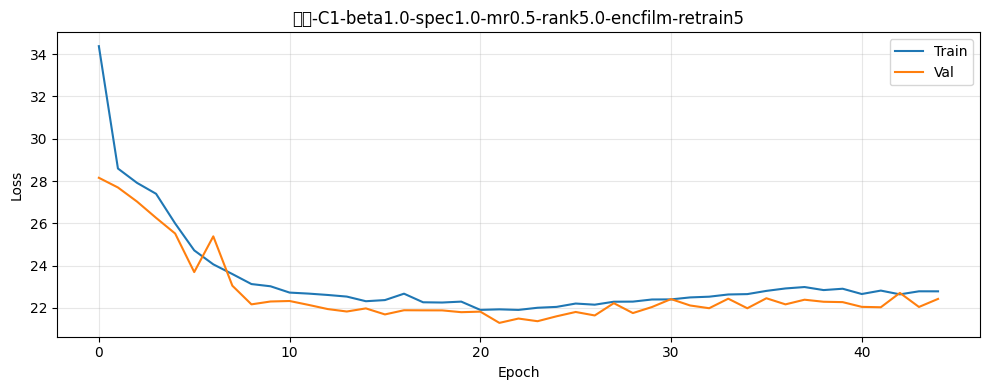

저장 완료


In [125]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train'], label='Train')
ax.plot(history['val'],   label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'{RUN_NAME}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'loss_curve.png'), dpi=150)
plt.show()
print('저장 완료')

In [ ]:
# 스펙트럼 추출 (HiFi-GAN 학습용)
SPEC_DIR = '/content/drive/MyDrive/ML_Project/outputs/spectrograms_film'
os.makedirs(SPEC_DIR, exist_ok=True)

def extract_spectrograms(loader, meta_df, split_name):
    out_dir = os.path.join(SPEC_DIR, split_name)
    os.makedirs(out_dir, exist_ok=True)
    saved = 0

    with torch.no_grad():
        for log_amp, cond, phase, wf in loader:
            log_amp = log_amp.to(device)
            cond    = cond.to(device)

            recon, _, _ = model(log_amp, cond)

            for i in range(log_amp.shape[0]):
                trace_name = meta_df.iloc[saved]['trace_name']
                safe_name  = trace_name.replace('/', '_')

                # (B, T, F) → (F, T) — HiFi-GAN 입력 형식
                recon_np = recon[i].cpu().numpy().T    # (F, T) [0,1] log10
                orig_np  = log_amp[i].cpu().numpy().T  # (F, T)
                phase_np = phase[i].cpu().numpy().T    # (F, T)
                wf_np    = wf[i].cpu().numpy()         # (6000,)

                np.save(os.path.join(out_dir, f'{safe_name}_recon.npy'),  recon_np)
                np.save(os.path.join(out_dir, f'{safe_name}_orig.npy'),   orig_np)
                np.save(os.path.join(out_dir, f'{safe_name}_phase.npy'),  phase_np)
                np.save(os.path.join(out_dir, f'{safe_name}_wf.npy'),     wf_np)

                saved += 1

        if saved % 1000 == 0 and saved > 0:
            print(f'[{split_name}] {saved}개 저장')

    print(f'✅ [{split_name}] 완료: {saved}개')

extract_spectrograms(train_loader, train_meta_s.reset_index(drop=True), 'train')
extract_spectrograms(val_loader,   val_meta_s.reset_index(drop=True),   'val')
extract_spectrograms(test_loader,  test_meta.reset_index(drop=True),    'test')

KeyboardInterrupt: 

## 8. 평가

In [126]:
# Best 모델 로드
ckpt = torch.load(os.path.join(SAVE_DIR, 'film_vae_best.pth'), map_location=device)
model.load_state_dict(ckpt['model'])
print(f'Best 모델 로드 (epoch={ckpt["epoch"]}, val={ckpt["val_loss"]:.4f})')
model.eval()
print(f'Best 모델 로드 (epoch={ckpt["epoch"]}, val={ckpt["val_loss"]:.4f})')
print(f'설정: {ckpt["config"]}')

Best 모델 로드 (epoch=22, val=21.2907)
Best 모델 로드 (epoch=22, val=21.2907)
설정: {'beta_max': 1.0, 'lambda_spectral': 1.0, 'lambda_mrstft': 0.5, 'lambda_rank': 5}


FAS residual (5~15Hz): 0.1147  ← 낮을수록 고주파 보존 좋음


/tmp/ipykernel_552/1887444716.py:37: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1887444716.py:37: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1887444716.py:37: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1887444716.py:37: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1887444716.py:37: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1887444716.py:37: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/1887444716.py:37: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

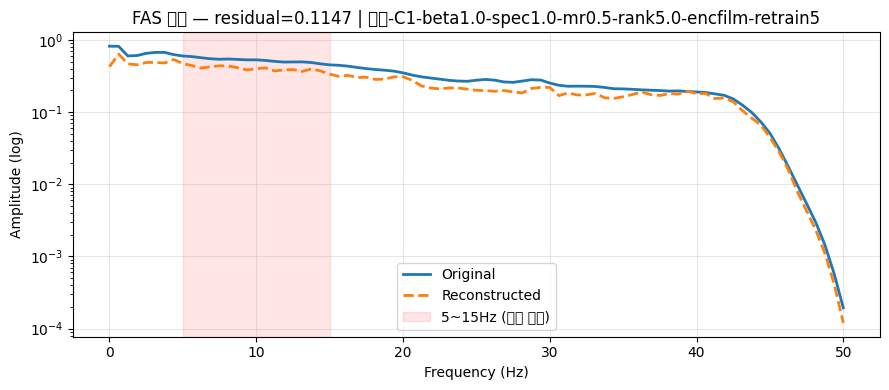

In [127]:
# FAS (Fourier Amplitude Spectrum) 비교 — 고주파 보존 확인
freqs = np.linspace(0, SR/2, N_FREQ)  # 0~50Hz, 81 bin
orig_fas_all, recon_fas_all = [], []

with torch.no_grad():
    for log_amp, cond, phase, wf in val_loader:
        log_amp = log_amp.to(device)
        cond    = cond.to(device)
        recon, _, _ = model(log_amp, cond)

        # 역정규화 → 선형 진폭
        orig_d  = log_amp.cpu() * (WFS_MAX - WFS_MIN) + WFS_MIN
        recon_d = recon.cpu()   * (WFS_MAX - WFS_MIN) + WFS_MIN
        orig_fas_all.append(torch.pow(10, orig_d).mean(dim=1).numpy())
        recon_fas_all.append(torch.pow(10, recon_d).mean(dim=1).numpy())

        if len(orig_fas_all) * BATCH_SIZE >= 500:
            break

orig_fas  = np.concatenate(orig_fas_all).mean(axis=0)
recon_fas = np.concatenate(recon_fas_all).mean(axis=0)

# FAS residual (5~15Hz 구간)
mask = (freqs >= 5) & (freqs <= 15)
fas_residual = np.abs(
    np.log10(orig_fas[mask] + 1e-10) - np.log10(recon_fas[mask] + 1e-10)
).mean()
print(f'FAS residual (5~15Hz): {fas_residual:.4f}  ← 낮을수록 고주파 보존 좋음')

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(freqs, orig_fas,  label='Original', lw=2)
ax.semilogy(freqs, recon_fas, label='Reconstructed', lw=2, ls='--')
ax.axvspan(5, 15, alpha=0.1, color='red', label='5~15Hz (평가 구간)')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Amplitude (log)')
ax.set_title(f'FAS 비교 — residual={fas_residual:.4f} | {RUN_NAME}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fas_comparison.png'), dpi=150)
plt.show()

/tmp/ipykernel_552/962929405.py:26: UserWarning: Glyph 51104 (\N{HANGUL SYLLABLE JAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/962929405.py:26: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/962929405.py:26: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/962929405.py:26: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/962929405.py:26: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/962929405.py:27: UserWarning: Glyph 51104 (\N{HANGUL SYLLABLE JAM}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, 'latent_space.png'), dpi=150)
/tmp/ipykernel_552/962929405.py:27: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing fro

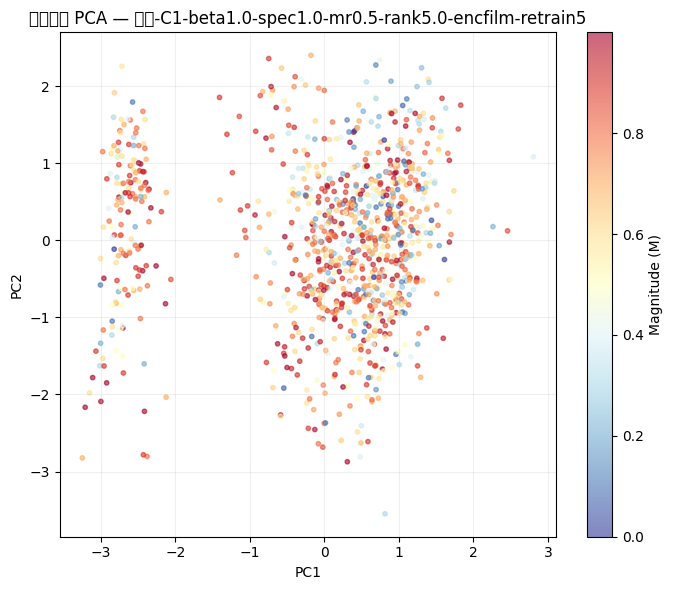

M별 색이 분리되면 FiLM 정상 작동!


In [128]:
# 잠재공간 시각화 (FiLM 조건 반영 확인)
# M별로 군집이 분리되어야 FiLM이 잘 작동한 것
all_mu, all_M = [], []

with torch.no_grad():
    for log_amp, cond, _, _ in val_loader:
        mu, _ = model.encoder(log_amp.to(device), cond.to(device))
        all_mu.append(mu.cpu().numpy())
        m_real = cond[:, 0].numpy() * (cond_max['source_magnitude'] - cond_min['source_magnitude'])                  + cond_min['source_magnitude']
        all_M.extend(m_real.tolist())
        if len(all_mu) * BATCH_SIZE >= 1000:
            break

all_mu = np.concatenate(all_mu)
all_M  = np.array(all_M)

pca = PCA(n_components=2)
z2d = pca.fit_transform(all_mu)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(z2d[:, 0], z2d[:, 1], c=all_M, cmap='RdYlBu_r', s=10, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Magnitude (M)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'잠재공간 PCA — {RUN_NAME}')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'latent_space.png'), dpi=150)
plt.show()
print('M별 색이 분리되면 FiLM 정상 작동!')

In [129]:
# 확인용
print(f"cond_max M: {cond_max['source_magnitude']}")
for M in [4.0, 5.0, 6.0, 7.0]:
    m_norm = (M - cond_min['source_magnitude']) / (cond_max['source_magnitude'] - cond_min['source_magnitude'])
    print(f"M={M} → 정규화값={m_norm:.4f}")

cond_max M: 8.0
M=4.0 → 정규화값=0.5249
M=5.0 → 정규화값=0.6437
M=6.0 → 정규화값=0.7625
M=7.0 → 정규화값=0.8812


/tmp/ipykernel_552/3958077645.py:45: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/3958077645.py:45: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/3958077645.py:45: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/3958077645.py:45: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/3958077645.py:45: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/3958077645.py:46: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, 'generated_waveforms.png'), dpi=150)
/tmp/ipykernel_552/3958077645.py:46: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEO

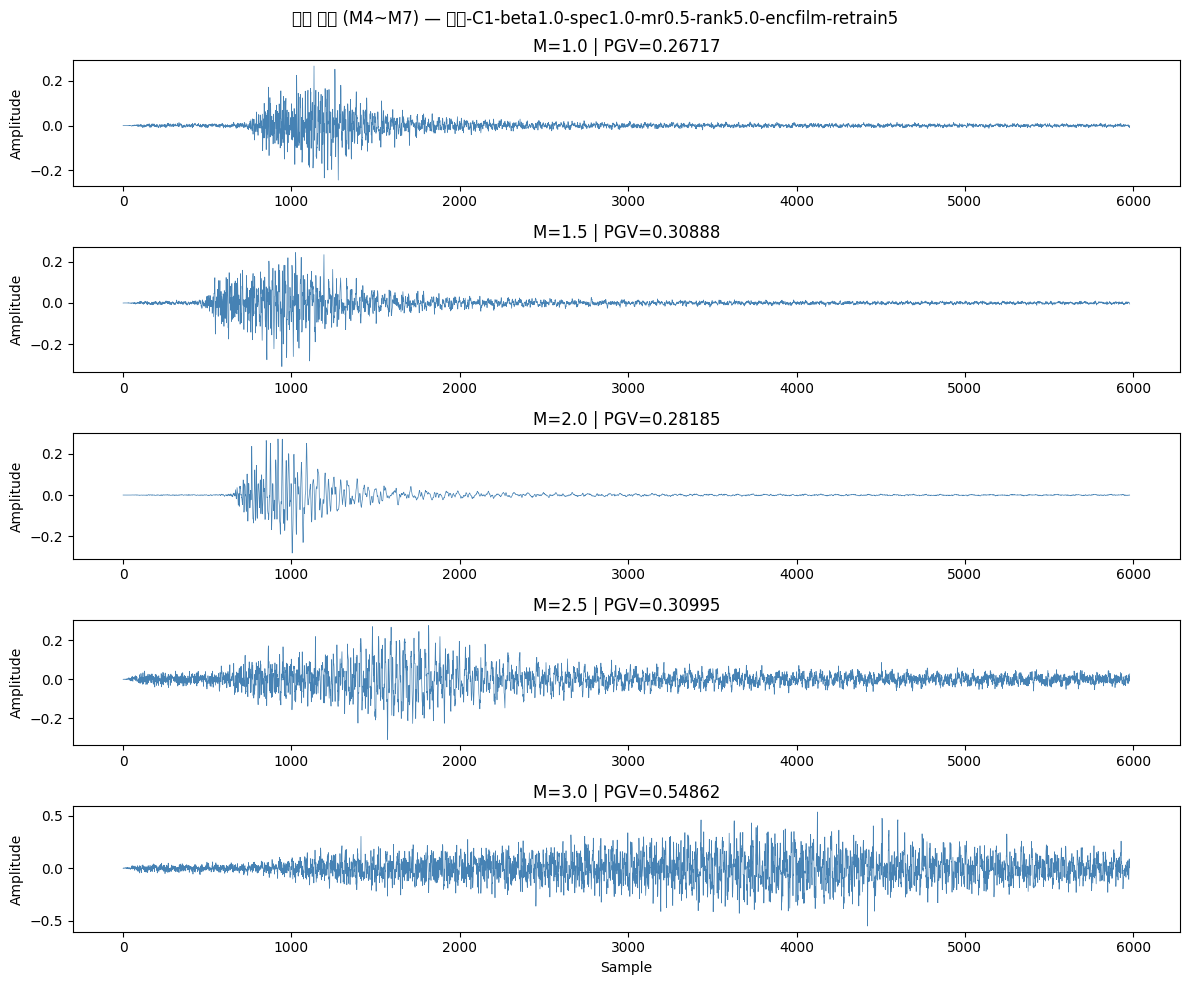


PGV 단조 증가 확인:
  M=1.0 → PGV=0.26717
  M=1.5 → PGV=0.30888
  M=2.0 → PGV=0.28185
  M=2.5 → PGV=0.30995
  M=3.0 → PGV=0.54862
⚠️  단조 증가 실패 — FiLM 재확인 필요


beta,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,█████████████████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▁▁▁▁▁
train/fas_hf,█▅▅▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/kl,█▆▅▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mrstft,█▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/rank,▁▁▁▁▂▂▂▃▃▄▄▅▅▅▆▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███
train/recon,█▅▅▅▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total,█▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▁▂▁▁
val/fas_hf,█▇▇▆▅▄▅▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▂▁
+4,...


eval/fas_residual_5_15hz,▁
eval/pgv_M4,▁
eval/pgv_M5,▁
eval/pgv_M6,▁
eval/pgv_M7,▁
eval/pgv_monotone,▁
eval/fas_residual_5_15hz,0.11466
eval/pgv_M4,0.26717
eval/pgv_M5,0.30888
eval/pgv_M6,0.28185
eval/pgv_M7,0.30995



평가 지표 wandb 업로드 완료


In [130]:
# PGV 단조 증가 확인 (M 클수록 PGV 커야 함)
griffinlim = torchaudio.transforms.GriffinLim(
    n_fft=N_FFT, n_iter=50, win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH, power=1.0
).to(device)

cond_mean = train_meta[COND_COLS].mean()
# 1단계 내삽
#M_targets = [1.0, 2.0, 3.0, 3.5, 3.9]

# 2단계 경계
# M_targets = [3.0, 3.5, 3.9, 4.0]

# 3단계 외삽
# M_targets = [4.0, 5.0, 6.0, 7.0]

# M=1, 1.5, 2, 2.5, 3 으로 변경
M_targets = [1.0, 1.5, 2.0, 2.5, 3.0]

pgv_list  = []

fig, axes = plt.subplots(5, 1, figsize=(12, 10))
for i, M in enumerate(M_targets):
    cvals = cond_mean.copy()
    cvals['source_magnitude'] = M
    ct = torch.tensor(
        [(cvals[c] - cond_min[c]) / (cond_max[c] - cond_min[c] + 1e-10) for c in COND_COLS],
        dtype=torch.float32
    ).unsqueeze(0).to(device).clamp(0, 1)

    with torch.no_grad():
        spec = model.generate(ct)[0].cpu()  # (T, F)

    mag = torch.pow(10, spec * (WFS_MAX - WFS_MIN) + WFS_MIN).T  # (F, T)
    wf  = griffinlim(mag.to(device)).cpu().numpy()
    pgv = np.abs(wf).max()
    pgv_list.append(pgv)

    axes[i].plot(wf, lw=0.5, color='steelblue')
    axes[i].set_title(f'M={M} | PGV={pgv:.5f}')
    axes[i].set_ylabel('Amplitude')

axes[-1].set_xlabel('Sample')
plt.suptitle(f'합성 파형 (M4~M7) — {RUN_NAME}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'generated_waveforms.png'), dpi=150)
plt.show()

print('\nPGV 단조 증가 확인:')
for M, pgv in zip(M_targets, pgv_list):
    print(f'  M={M} → PGV={pgv:.5f}')

is_monotone = all(pgv_list[i] <= pgv_list[i+1] for i in range(len(pgv_list)-1))
print('✅ 단조 증가 확인' if is_monotone else '⚠️  단조 증가 실패 — FiLM 재확인 필요')

# 평가 결과 wandb에 최종 기록
wandb.init(
    entity=WANDB_ENTITY, project=WANDB_PROJECT,
    name=RUN_NAME, resume='allow'
)
wandb.log({
    'eval/fas_residual_5_15hz': fas_residual,
    'eval/pgv_M4': pgv_list[0],
    'eval/pgv_M5': pgv_list[1],
    'eval/pgv_M6': pgv_list[2],
    'eval/pgv_M7': pgv_list[3],
    'eval/pgv_monotone': int(is_monotone),
})
wandb.finish()
print('\n평가 지표 wandb 업로드 완료')

/tmp/ipykernel_552/4075285864.py:34: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/4075285864.py:34: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/4075285864.py:34: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/4075285864.py:34: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/4075285864.py:34: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_552/4075285864.py:35: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, 'generated_waveforms.png'), dpi=150)
/tmp/ipykernel_552/4075285864.py:35: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEO

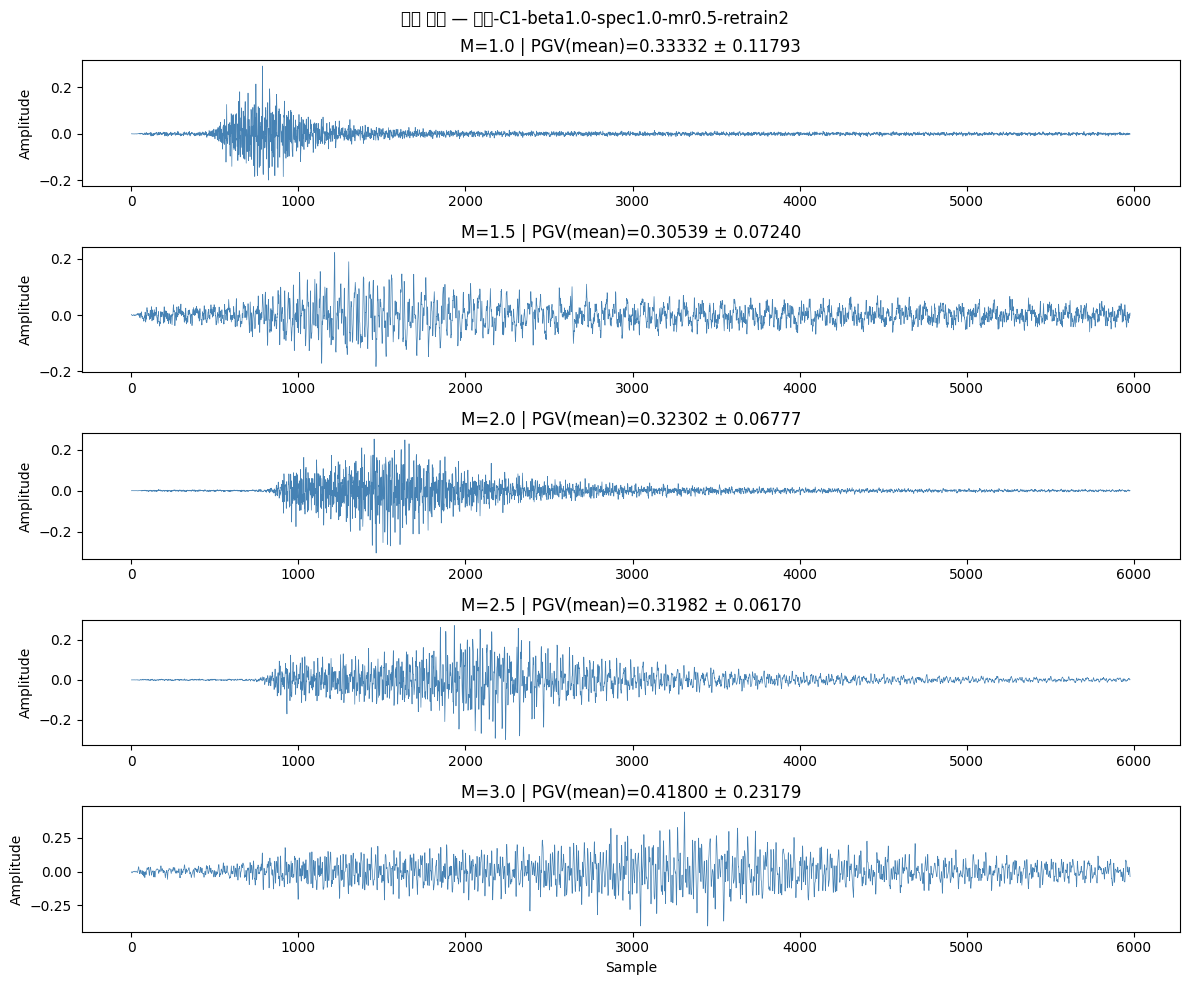


PGV 단조 증가 확인 (N=20 평균):
  M=1.0 → PGV=0.33332
  M=1.5 → PGV=0.30539
  M=2.0 → PGV=0.32302
  M=2.5 → PGV=0.31982
  M=3.0 → PGV=0.41800
⚠️  단조 증가 실패 — FiLM 재확인 필요


In [66]:
N_SAMPLES = 20  # 샘플링 횟수

M_targets = [1.0, 1.5, 2.0, 2.5, 3.0]
pgv_list  = []
fig, axes = plt.subplots(5, 1, figsize=(12, 10))

for i, M in enumerate(M_targets):
    cvals = cond_mean.copy()
    cvals['source_magnitude'] = M
    ct = torch.tensor(
        [(cvals[c] - cond_min[c]) / (cond_max[c] - cond_min[c] + 1e-10) for c in COND_COLS],
        dtype=torch.float32
    ).unsqueeze(0).to(device).clamp(0, 1)

    # 20번 샘플링해서 평균 PGV
    pgv_samples = []
    with torch.no_grad():
        for _ in range(N_SAMPLES):
            spec = model.generate(ct)[0].cpu()
            mag = torch.pow(10, spec * (WFS_MAX - WFS_MIN) + WFS_MIN).T
            wf  = griffinlim(mag.to(device)).cpu().numpy()
            pgv_samples.append(np.abs(wf).max())

    pgv = np.mean(pgv_samples)
    pgv_list.append(pgv)

    # 플롯은 마지막 샘플 1개로
    axes[i].plot(wf, lw=0.5, color='steelblue')
    axes[i].set_title(f'M={M} | PGV(mean)={pgv:.5f} ± {np.std(pgv_samples):.5f}')
    axes[i].set_ylabel('Amplitude')

axes[-1].set_xlabel('Sample')
plt.suptitle(f'합성 파형 — {RUN_NAME}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'generated_waveforms.png'), dpi=150)
plt.show()

print('\nPGV 단조 증가 확인 (N=20 평균):')
for M, pgv in zip(M_targets, pgv_list):
    print(f'  M={M} → PGV={pgv:.5f}')
is_monotone = all(pgv_list[i] <= pgv_list[i+1] for i in range(len(pgv_list)-1))
print('✅ 단조 증가 확인' if is_monotone else '⚠️  단조 증가 실패 — FiLM 재확인 필요')

## 9. GitHub push

In [133]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
REPO_DIR = '/content/seismic-gen'
REPO_URL = f'https://{GITHUB_TOKEN}@github.com/isseul/cose362-k08-seismic-generation.git'

if not os.path.exists(REPO_DIR):
    os.system(f'git clone {REPO_URL} {REPO_DIR}')

os.system(f'cd {REPO_DIR} && git fetch origin')
os.system(f'cd {REPO_DIR} && git checkout vae-dev')
os.makedirs(f'{REPO_DIR}/vae', exist_ok=True)

NOTEBOOK_SRC = '/content/drive/MyDrive/Colab Notebooks/04_film_vae_train_filmfixed.ipynb'
NOTEBOOK_DST = f'{REPO_DIR}/vae/04_film_vae_train_filmfixed.ipynb'

if os.path.exists(NOTEBOOK_SRC):
    os.system(f'cp "{NOTEBOOK_SRC}" "{NOTEBOOK_DST}"')
    os.system(f'cd {REPO_DIR} && git config user.email "team-k8@example.com"')
    os.system(f'cd {REPO_DIR} && git config user.name "Team-K8"')
    os.system(f'cd {REPO_DIR} && git add vae/04_film_vae_train_fixed.ipynb')
    os.system(f'cd {REPO_DIR} && git commit -m "feat(vae): {RUN_NAME} 학습 완료"')
    os.system(f'cd {REPO_DIR} && git push origin vae-dev')
    print('GitHub push 완료!')
else:
    print(f'노트북 파일 없음: {NOTEBOOK_SRC}')
    print('Drive에 저장 후 경로 수정하세요')

GitHub push 완료!
